In [1]:
from pathlib import Path
import numpy as np
import torch
from PIL import Image
import json

LOCATION = "cattedralesanlorenzo"  # cambia con il nome della tua cartella

DATASET_DIR = Path("foto") / LOCATION
OUTPUT_DIR = Path("output") / LOCATION
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Device: {device}")
print(f"Foto in: {DATASET_DIR}")
print(f"Output in: {OUTPUT_DIR}")

Device: mps
Foto in: foto/cattedralesanlorenzo
Output in: output/cattedralesanlorenzo


In [5]:
# Trova tutte le immagini .jpg
image_paths = sorted(DATASET_DIR.glob("*.jpg"))

# Aggiungi varianti di estensione (case-insensitive)
image_paths += sorted(DATASET_DIR.glob("*.JPG"))
image_paths += sorted(DATASET_DIR.glob("*.jpeg"))

# Rimuovi duplicati e ordina
image_paths = sorted(set(image_paths))

print(f"Trovate {len(image_paths)} immagini")
print(f"\nPrime 5:")
for p in image_paths[:5]:
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name} ({size_kb:.0f} KB)")

print(f"\nUltime 5:")
for p in image_paths[-5:]:
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name} ({size_kb:.0f} KB)")

Trovate 758 immagini

Prime 5:
  1231967687424126913_01.jpg (189 KB)
  1242649458791592427_01.jpg (266 KB)
  1495982379931966739_01.jpg (127 KB)
  1497930011176134851_01.jpg (126 KB)
  1529770506478333149_01.jpg (363 KB)

Ultime 5:
  3865728587199206733_01.jpg (276 KB)
  3868748400246152393_01.jpg (207 KB)
  3873277989995682567_01.jpg (456 KB)
  3881784931928158879_01.jpg (209 KB)
  523479428924581451_01.jpg (100 KB)


In [3]:
from transformers import AutoImageProcessor, AutoModel

model_name = "facebook/dinov2-large"

print(f"Caricamento {model_name}...")
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

print("Modello DINOv2 ViT-L caricato!")
print(f"Device: {device}")

Caricamento facebook/dinov2-large...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Modello DINOv2 ViT-L caricato!
Device: mps


In [6]:
from tqdm.notebook import tqdm
from sklearn.preprocessing import normalize

embeddings = []
valid_paths = []
errors = []

with torch.no_grad():
    for path in tqdm(image_paths, desc="Estrazione embedding DINOv2"):
        try:
            image = Image.open(path).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(device)
            features = model(**inputs)
            emb = features.pooler_output.cpu().numpy()[0]
            embeddings.append(emb)
            valid_paths.append(path)
        except Exception as e:
            errors.append((path.name, str(e)))

embeddings = np.array(embeddings)
embeddings_normalized = normalize(embeddings)

print(f"\nEmbedding estratti: {embeddings.shape}")
print(f"Errori: {len(errors)}")

np.save(OUTPUT_DIR / "embeddings_dinov2.npy", embeddings_normalized)
paths_str = [str(p) for p in valid_paths]
with open(OUTPUT_DIR / "paths_dinov2.json", "w") as f:
    json.dump(paths_str, f, indent=2)

print(f"Salvati in {OUTPUT_DIR}")

Estrazione embedding DINOv2:   0%|          | 0/758 [00:00<?, ?it/s]


Embedding estratti: (758, 1024)
Errori: 0
Salvati in output/cattedralesanlorenzo


In [7]:
import hdbscan
from collections import Counter

labels = hdbscan.HDBSCAN(
    min_cluster_size=6,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom'
).fit_predict(embeddings_normalized)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n=== RISULTATI DINOv2 ===")
print(f"Cluster identificati: {n_clusters}")
print(f"Foto in cluster: {len(labels) - n_noise} ({100*(len(labels) - n_noise)/len(labels):.1f}%)")
print(f"Foto rumore: {n_noise} ({100*n_noise/len(labels):.1f}%)")

print(f"\n=== TUTTI I CLUSTER ===")
counter = Counter(labels)
for cluster_id, count in sorted(counter.items(), key=lambda x: -x[1]):
    if cluster_id == -1:
        continue
    print(f"Cluster {cluster_id:3d}: {count:4d} foto")

cluster_ordinati = [c for c, _ in sorted(counter.items(), key=lambda x: -x[1]) if c != -1]


=== RISULTATI DINOv2 ===
Cluster identificati: 10
Foto in cluster: 505 (66.6%)
Foto rumore: 253 (33.4%)

=== TUTTI I CLUSTER ===
Cluster   4:  328 foto
Cluster   7:   55 foto
Cluster   8:   51 foto
Cluster   6:   16 foto
Cluster   3:   12 foto
Cluster   5:   10 foto
Cluster   9:   10 foto
Cluster   1:    9 foto
Cluster   2:    8 foto
Cluster   0:    6 foto


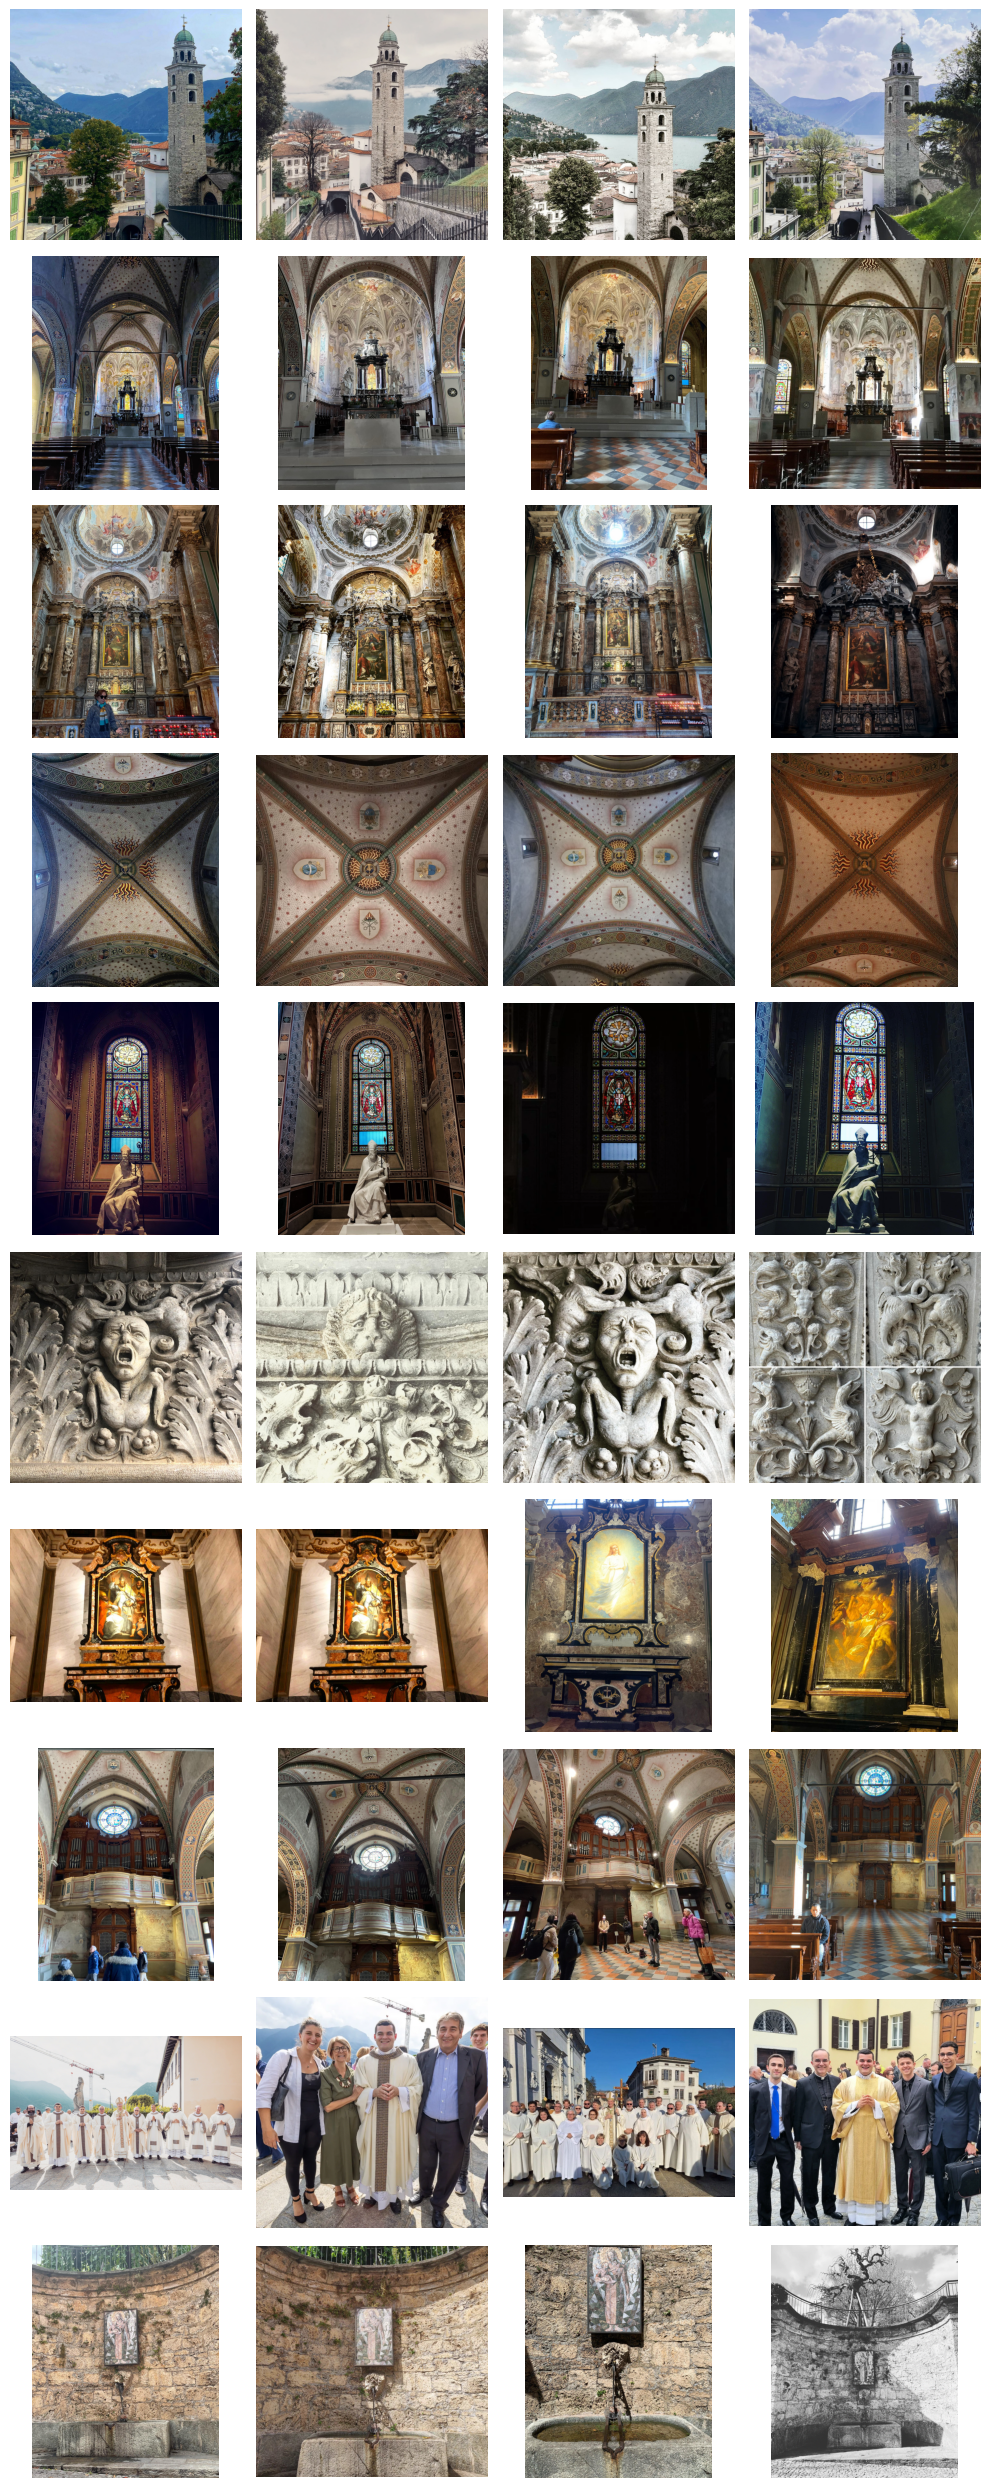

In [8]:
import matplotlib.pyplot as plt

def panoramica_cluster(cluster_ids, n_per_cluster=4):
    n_clusters_show = len(cluster_ids)
    fig, axes = plt.subplots(n_clusters_show, n_per_cluster, 
                              figsize=(n_per_cluster*2.5, n_clusters_show*2.5))
    if n_clusters_show == 1:
        axes = [axes]
    for row, cid in enumerate(cluster_ids):
        indici = np.where(labels == cid)[0]
        cluster_emb = embeddings_normalized[indici]
        centroide = cluster_emb.mean(axis=0)
        centroide = centroide / np.linalg.norm(centroide)
        distanze = np.linalg.norm(cluster_emb - centroide, axis=1)
        indici_ordinati = indici[np.argsort(distanze)][:n_per_cluster]
        for col, idx in enumerate(indici_ordinati):
            img = Image.open(valid_paths[idx])
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_ylabel(f"C{cid}\n({len(indici)})", 
                                            rotation=0, ha='right', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

panoramica_cluster(cluster_ordinati, n_per_cluster=4)

Cluster validi: [np.int64(23), np.int64(11), np.int64(10), np.int64(9), np.int64(0), np.int64(13)]
Esclusi: [20, 24, 15, 7, 19, 3, 1, 18, 4, 2, 22, 12, 16, 5, 6, 14, 17, 21, 8]

  C23: 290 foto
  C11: 10 foto
  C10: 9 foto
  C9: 7 foto
  C0: 7 foto
  C13: 7 foto


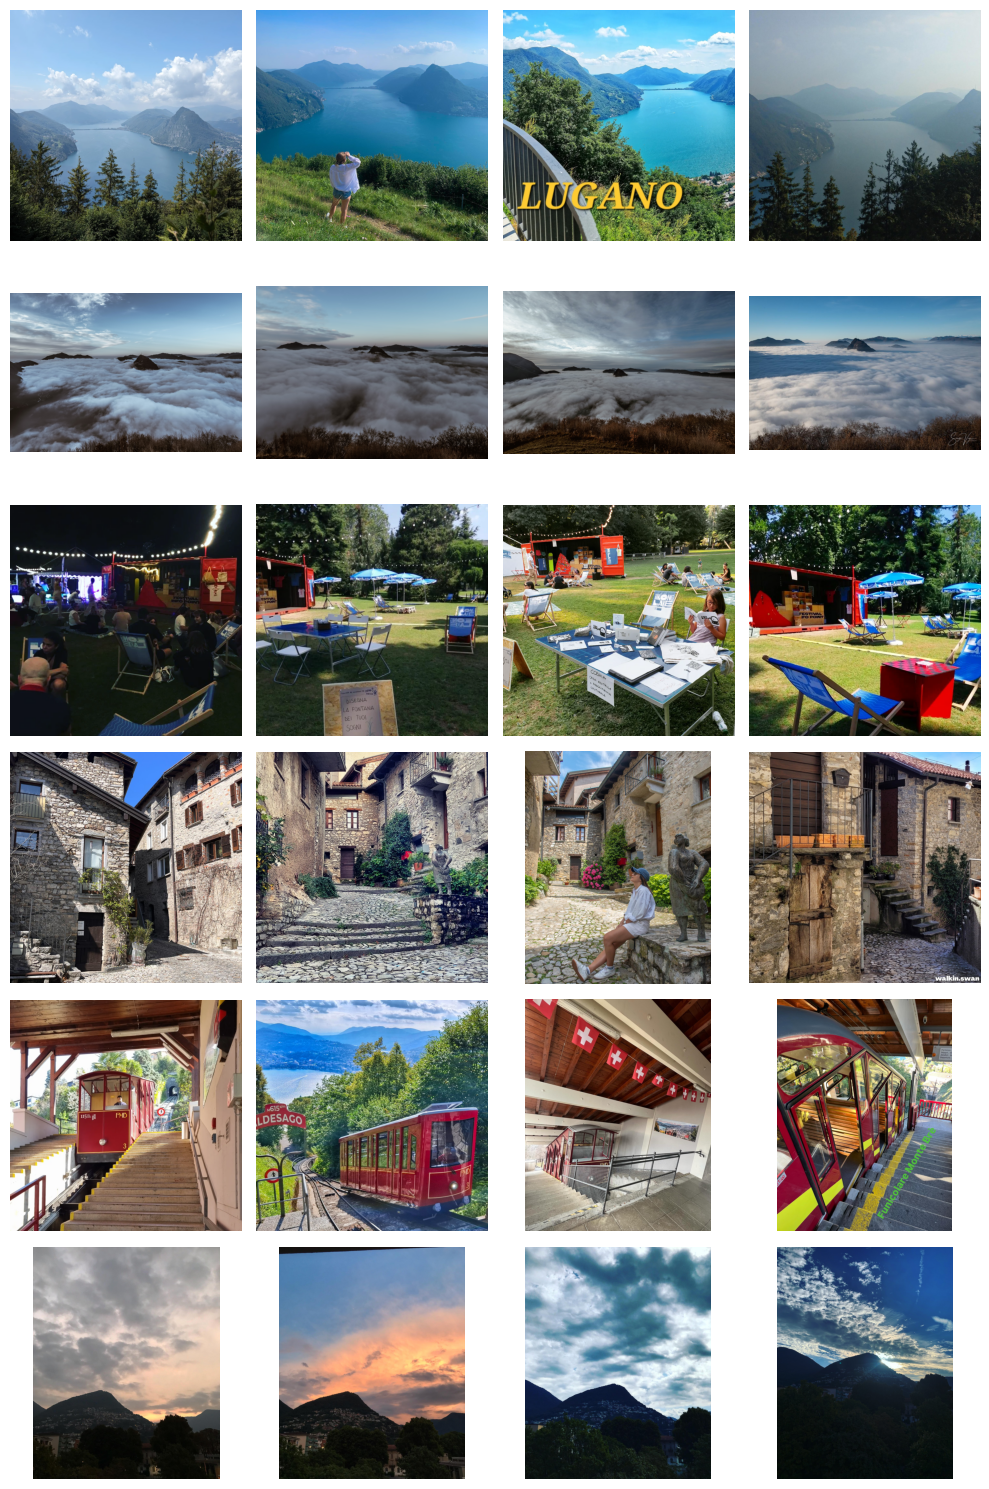

In [15]:
# Escludi cluster spuri
ESCLUSI = [20, 24, 15, 7, 19, 3, 1, 18, 4, 2, 22, 12, 16, 5, 6, 14, 17, 21,8]  # esempio: cluster 3 e 7 non mi interessano
CLUSTER_VALIDI = [c for c in cluster_ordinati if c not in ESCLUSI]

print(f"Cluster validi: {CLUSTER_VALIDI}")
print(f"Esclusi: {ESCLUSI}\n")

for cid in CLUSTER_VALIDI:
    n = list(labels).count(cid)
    print(f"  C{cid}: {n} foto")

# Panoramica visiva dei soli cluster validi
panoramica_cluster(CLUSTER_VALIDI, n_per_cluster=4)

In [26]:
from dotenv import load_dotenv
import os

# Carica il .env
load_dotenv()

# Verifica che la chiave sia stata caricata
api_key = os.getenv("GEMINI_API_KEY")
if api_key:
    print(f"✅ API key caricata correttamente (lunghezza: {len(api_key)} caratteri)")
    print(f"Inizia con: {api_key[:8]}...")
else:
    print("❌ API key non trovata. Controlla che il file .env sia in /Pipeline/")

✅ API key caricata correttamente (lunghezza: 39 caratteri)
Inizia con: AIzaSyBl...


In [28]:
def descrivi_cluster_gemini(cluster_id, n_foto=4):
    indici = np.where(labels == cluster_id)[0]
    cluster_emb = embeddings_normalized[indici]
    centroide = cluster_emb.mean(axis=0)
    centroide = centroide / np.linalg.norm(centroide)
    distanze = np.linalg.norm(cluster_emb - centroide, axis=1)
    indici_ordinati = indici[np.argsort(distanze)][:n_foto]
    
    images = [Image.open(valid_paths[idx]) for idx in indici_ordinati]
    
    prompt = """These photos were clustered together by an AI as visually similar tourist photos from Parco Ciani, a public park in Lugano, Switzerland.

Analyze them and identify the common subject — likely an iconic landmark or recurring view.

Respond with ONLY a valid JSON object (no markdown fences, no extra text):
{
  "label": "short label of 3-5 words in English",
  "description": "1-2 sentences describing what is depicted",
  "search_prompt": "a concise visual description suitable for an object detection model",
  "confidence": 0.0
}

confidence is a float 0-1 indicating how coherent the cluster is."""
    
    response = model_vlm.generate_content([prompt] + images)
    return response.text

# Test sul cluster più grande
cid_test = cluster_ordinati[0]
print(f"Test su Cluster {cid_test}...\n")
result = descrivi_cluster_gemini(cid_test, n_foto=4)
print(result)

Test su Cluster 4...



NameError: name 'model_vlm' is not defined

In [20]:
CLUSTER_VALIDI = list(cluster_ordinati)
print(f"Cluster da processare: {CLUSTER_VALIDI}")

Cluster da processare: [np.int64(4), np.int64(7), np.int64(8), np.int64(6), np.int64(3), np.int64(5), np.int64(9), np.int64(1), np.int64(2), np.int64(0)]


In [17]:
import re
import time

hotspots = []

for cid in CLUSTER_ORDINATI:
    print(f"Processo Cluster {cid}...")
    try:
        raw_response = descrivi_cluster_gemini(cid, n_foto=4)
        cleaned = re.sub(r'```json\s*|\s*```', '', raw_response).strip()
        data = json.loads(cleaned)
        
        indici = np.where(labels == cid)[0]
        cluster_emb = embeddings_normalized[indici]
        centroide = cluster_emb.mean(axis=0)
        centroide = centroide / np.linalg.norm(centroide)
        distanze = np.linalg.norm(cluster_emb - centroide, axis=1)
        indici_ordinati = indici[np.argsort(distanze)]
        rappresentative = [str(valid_paths[idx]) for idx in indici_ordinati[:8]]
        
        hotspot = {
            "cluster_id": int(cid),
            "size": int(len(indici)),
            "label": data.get("label", ""),
            "description": data.get("description", ""),
            "search_prompt": data.get("search_prompt", ""),
            "confidence": float(data.get("confidence", 0)),
            "representative_photos": rappresentative
        }
        hotspots.append(hotspot)
        print(f"  ✓ {hotspot['label']} (conf: {hotspot['confidence']})")
        
        time.sleep(2)  # rate limit Gemini gratuito
        
    except json.JSONDecodeError as e:
        print(f"  ✗ Errore parsing JSON: {e}")
        print(f"  Raw: {raw_response[:300]}")
    except Exception as e:
        print(f"  ✗ Errore: {e}")

# Ordina per dimensione
hotspots.sort(key=lambda h: -h["size"])

# Salva il file finale
hotspots_path = OUTPUT_DIR / "hotspots.json"
with open(hotspots_path, "w") as f:
    json.dump(hotspots, f, indent=2, ensure_ascii=False)

print(f"\n=== HOTSPOT SALVATI in {hotspots_path} ===\n")
for h in hotspots:
    print(f"  C{h['cluster_id']:2d} ({h['size']:3d} foto): {h['label']:40s} [conf: {h['confidence']:.2f}]")

NameError: name 'CLUSTER_ORDINATI' is not defined

In [11]:
# === Salva mapping completo cluster → foto ===
import json

# Usa solo i 3 cluster che ci servono
CLUSTER_EXPORT = [4, 7, 8, 6, 3, 5, 9, 1, 2, 0]

cluster_photos = {}
for cid in CLUSTER_EXPORT:
    indici = np.where(labels == cid)[0]
    cluster_photos[str(cid)] = [str(valid_paths[i]) for i in indici]

# Salva
with open(OUTPUT_DIR / "cluster_photos.json", "w") as f:
    json.dump(cluster_photos, f, indent=2)

# Verifica
for cid, photos in cluster_photos.items():
    print(f"Cluster {cid}: {len(photos)} foto")
print(f"\nSalvato in {OUTPUT_DIR / 'cluster_photos.json'}")

Cluster 4: 328 foto
Cluster 7: 55 foto
Cluster 8: 51 foto
Cluster 6: 16 foto
Cluster 3: 12 foto
Cluster 5: 10 foto
Cluster 9: 10 foto
Cluster 1: 9 foto
Cluster 2: 8 foto
Cluster 0: 6 foto

Salvato in output/cattedralesanlorenzo/cluster_photos.json
